In [1]:
# imports

import numpy as np
import matplotlib.pyplot as plt

In [2]:
# data 

# substrate concentration 
S = np.array([0.2, 0.4, 0.8, 1.0, 2.0, 4.0]) # mM

# reaction rate v without any inhibitor and with different inhibitors A and B
v_no_inh = np.array([5.0, 7.5, 10.0, 10.7, 12.5, 13.6]) # mM/min
v_A  = np.array([3.0, 5.0, 7.5, 8.3, 10.7, 12.5]) # mM/min
v_B  = np.array([2.0, 3.0, 4.0, 4.3, 5.0, 5.5]) # mM/min

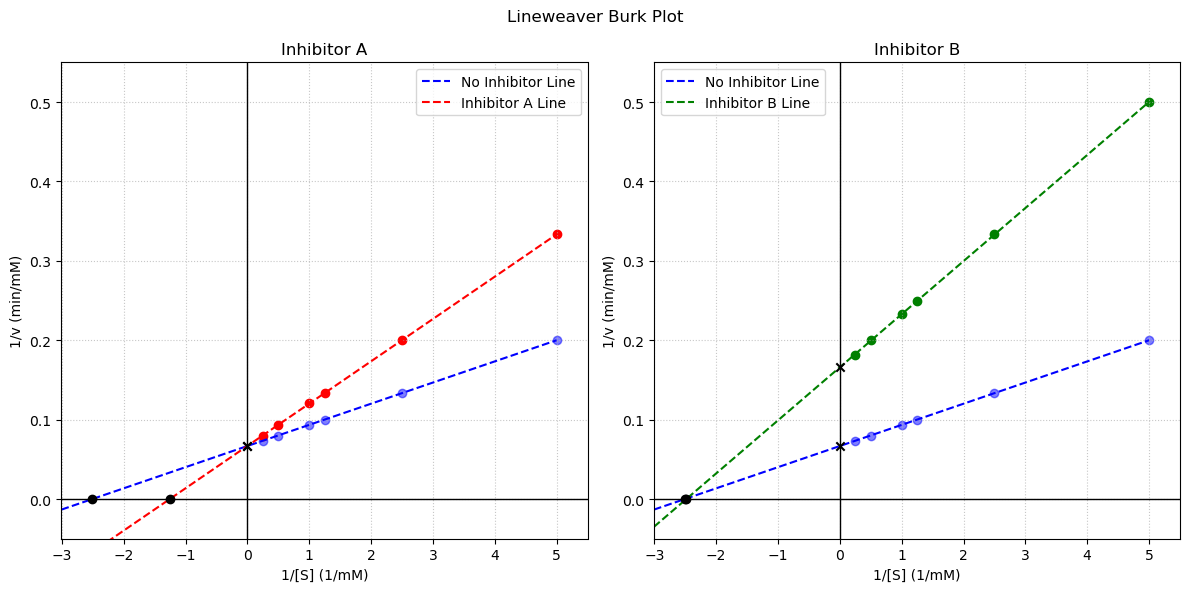

In [3]:
# a)

# reciprocals 
inv_S = 1/S
inv_v_no_inh = 1/ v_no_inh
inv_v_A = 1/ v_A
inv_v_B = 1/ v_B

# Linewear-Burk plot
fig, axs = plt.subplots(1,2, figsize=(12, 6))
fig.suptitle('Lineweaver Burk Plot')

# inhibitors 
inh_data = [
    {'name': 'Inhibitor A', 'y': inv_v_A, 'col': 'red', 'ax': axs[0]},
    {'name': 'Inhibitor B', 'y': inv_v_B, 'col': 'green', 'ax': axs[1]}
] 

for inhibitor in inh_data:
    ax = inhibitor['ax']
    # Fit inhibitor line
    m_i, b_i = np.polyfit(inv_S, inhibitor['y'], 1)
    x_int_i = -b_i / m_i
    
    # no inhibitor 
    m_no_inh, b_no_inh = np.polyfit(inv_S,inv_v_no_inh,1) 
    x_int_no = -b_no_inh / m_no_inh

    # X range 
    x_min = min(x_int_no, x_int_i) * 1.2
    x_range = np.linspace(x_min, max(inv_S), 100)
    
    # plot no inhibitor 
    ax.plot(x_range, m_no_inh * x_range + b_no_inh, color='blue', linestyle='--', label='No Inhibitor Line')
    ax.scatter(inv_S, inv_v_no_inh, color='blue', alpha=0.5)
    
    # plot inhibitor
    ax.plot(x_range, m_i * x_range + b_i, color=inhibitor['col'], linestyle='--', label=f'{inhibitor["name"]} Line')
    ax.scatter(inv_S, inhibitor['y'], color=inhibitor['col'])
    
    # intercepts
    ax.scatter([x_int_no, x_int_i], [0, 0], color='black', zorder=5) 
    ax.scatter([0, 0], [b_no_inh, b_i], color='black', marker='x', zorder=5) 

    ax.set_title(inhibitor['name'])
    ax.set_xlabel('1/[S] (1/mM)')
    ax.set_ylabel('1/v (min/mM)')
    ax.axhline(0, color='black', linewidth=1)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_xlim(x_min, max(inv_S) * 1.1)
    ax.set_ylim(-0.05, max(inv_v_B) * 1.1)
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend()

plt.tight_layout()
plt.show()


In [4]:
# b) 

def kinetics(m, b, label):
    v_max = 1 / b
    k_m = m * v_max
    print(f"{label} :")
    print(f"Slope (m): {m:.4f}")
    print(f"Y-intercept (b): {b:.4f}")
    print(f"Vmax: {v_max:.2f} mM/min")
    print(f"Km: {k_m:.2f} mM")
    print("-----")
    return v_max, k_m

# no inhibitor
m_no_inh, b_no_inh = np.polyfit(inv_S, inv_v_no_inh, 1)
vmax_no, km_no = kinetics(m_no_inh, b_no_inh, "No Inhibitor")

# inhibitor A
m_A, b_A = np.polyfit(inv_S, inv_v_A, 1)
vmax_A, km_A = kinetics(m_A, b_A, "Inhibitor A")

# inhibitor B
m_B, b_B = np.polyfit(inv_S, inv_v_B, 1)
vmax_B, km_B = kinetics(m_B, b_B, "Inhibitor B")

No Inhibitor :
Slope (m): 0.0266
Y-intercept (b): 0.0668
Vmax: 14.98 mM/min
Km: 0.40 mM
-----
Inhibitor A :
Slope (m): 0.0533
Y-intercept (b): 0.0668
Vmax: 14.96 mM/min
Km: 0.80 mM
-----
Inhibitor B :
Slope (m): 0.0668
Y-intercept (b): 0.1660
Vmax: 6.03 mM/min
Km: 0.40 mM
-----


[I] (mM)   Vmax (mM/min)   Km (mM)   Slope      
---------------------------------------------
1          14.50           1.23       0.08469577414825374
2          13.88           1.78       0.128287148918953
3          15.02           2.79       0.1855038139074637
4          14.31           3.31       0.23149287718793615


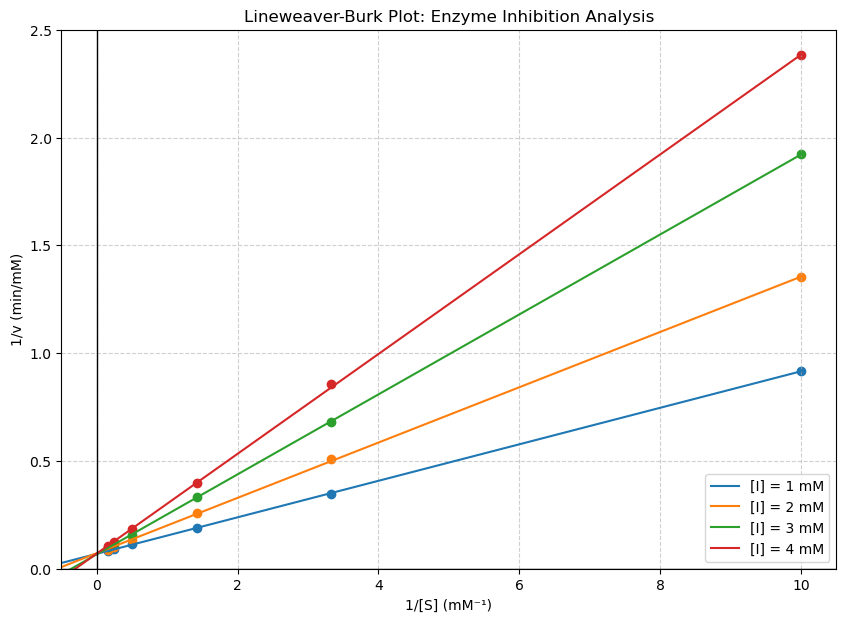

In [5]:
# d)

from scipy.stats import linregress

# data 
S = np.array([0.1, 0.3, 0.7, 2.0, 4.0, 6.0]) #mM
I = np.array([1, 2, 3, 4]) # mM

# reaction rates v for each [I]
v_data = { # (mM/min)
    1: np.array([1.09, 2.89, 5.24, 8.85, 10.89, 12.11]),
    2: np.array([0.74, 1.96, 3.89, 7.40, 9.82, 11.36]),
    3: np.array([0.52, 1.47, 3.01, 6.31, 8.76, 10.02]),
    4: np.array([0.42, 1.17, 2.51, 5.43, 8.07, 9.37])
}

inv_S = 1/S

# table with vmax and Km for each case
print(f"{'[I] (mM)':<10} {'Vmax (mM/min)':<15} {'Km (mM)':<10}{'Slope':<10} ")
print("-" * 45)

plt.figure(figsize=(10, 7))

# for each inhibitor concentration
for i in I:
    v = v_data[i]
    inv_v = 1 / v
    
    # 1/v = (Km/Vmax) * (1/S) + (1/Vmax)
    slope, intercept, r_value, p_value, std_err = linregress(inv_S, inv_v)
    
    # kinetic parameters
    vmax = 1 / intercept
    km = slope * vmax
    
    print(f"{i:<10} {vmax:<15.2f} {km:<10.2f} {slope:<10}")

    x_fit = np.linspace(-0.5, 10, 100)
    y_fit = slope * x_fit + intercept
    
    plt.plot(x_fit, y_fit, label=f'[I] = {i} mM')
    plt.scatter(inv_S, inv_v)

plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.title('Lineweaver-Burk Plot: Enzyme Inhibition Analysis')
plt.xlabel('1/[S] (mM⁻¹)')
plt.ylabel('1/v (min/mM)')
plt.xlim(-0.5, 10.5)
plt.ylim(0, 2.5)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [6]:
# without inhibitor
Km_0 = 0.40      # mM
Vmax_0 = 15.0    # mM/min
m_0 = Km_0 / Vmax_0

print("\nReference values without inhibitor:")
print(f"Km_0   = {Km_0:.2f} mM")
print(f"Vmax_0 = {Vmax_0:.2f} mM/min")
print(f"m_0    = {m_0:.5f}")

# store K_I values
KI_values = []

print(f"\n{'[I] (mM)':<10} {'Slope m':<12} {'m/m0':<12} {'K_I (mM)':<12}")
print("-" * 46)

# loop again through each inhibitor concentration
for i in I:
    v = v_data[i]
    inv_v = 1 / v
    
    # fit Lineweaver-Burk line
    slope, intercept, r_value, p_value, std_err = linregress(inv_S, inv_v)
    
    # competitive inhibition relation:
    # m/m0 = 1 + [I]/K_I
    slope_ratio = slope / m_0
    KI = i / (slope_ratio - 1)
    
    KI_values.append(KI)
    
    print(f"{i:<10} {slope:<12.5f} {slope_ratio:<12.3f} {KI:<12.3f}")

# average K_I
KI_avg = np.mean(KI_values)

print("\nEstimated K_I values:")
print(KI_values)
print(f"\nAverage K_I ≈ {KI_avg:.2f} mM")


Reference values without inhibitor:
Km_0   = 0.40 mM
Vmax_0 = 15.00 mM/min
m_0    = 0.02667

[I] (mM)   Slope m      m/m0         K_I (mM)    
----------------------------------------------
1          0.08470      3.176        0.460       
2          0.12829      4.811        0.525       
3          0.18550      6.956        0.504       
4          0.23149      8.681        0.521       

Estimated K_I values:
[np.float64(0.4595394936089296), np.float64(0.5248285793500396), np.float64(0.5036605189006577), np.float64(0.520766685060505)]

Average K_I ≈ 0.50 mM
